### 1. Generate Synthetic Dataset

I will create a synthetic dataset with features like `timestamp`, `sleep_duration`, `activity_level`, and `heart_rate`. I will also introduce some anomalies to simulate unusual patterns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Set random seed for reproducibility
np.random.seed(42)

# Generate timestamps for a month
dates = pd.date_range(start='2023-01-01', periods=30 * 24, freq='H') # Hourly data for 30 days

# Generate 'normal' sleep and activity patterns
sleep_duration = np.sin(np.arange(len(dates)) / 24 * 2 * np.pi / 7) * 2 + 7 # Daily cycle, weekly variation
activity_level = np.cos(np.arange(len(dates)) / 24 * 2 * np.pi / 7) * 0.3 + 0.5 # Inverse of sleep
heart_rate = np.random.normal(loc=70, scale=5, size=len(dates))

# Introduce anomalies
anomaly_indices = np.random.choice(len(dates), size=30, replace=False)

# High activity during sleep time
sleep_duration[anomaly_indices[0:10]] = np.random.uniform(2, 4, size=10) # Unusually low sleep
activity_level[anomaly_indices[0:10]] = np.random.uniform(0.8, 1.2, size=10) # Unusually high activity

# Unusually high heart rate
heart_rate[anomaly_indices[10:20]] = np.random.normal(loc=100, scale=10, size=10)

# Unusually long sleep with low activity
sleep_duration[anomaly_indices[20:30]] = np.random.uniform(10, 12, size=10)
activity_level[anomaly_indices[20:30]] = np.random.uniform(0.1, 0.3, size=10)

# Create DataFrame
df = pd.DataFrame({
    'timestamp': dates,
    'sleep_duration': sleep_duration,
    'activity_level': activity_level,
    'heart_rate': heart_rate
})

# Add some noise
df['sleep_duration'] += np.random.normal(0, 0.5, len(dates))
df['activity_level'] += np.random.normal(0, 0.1, len(dates))

# Ensure non-negative values
df['sleep_duration'] = df['sleep_duration'].apply(lambda x: max(x, 0))
df['activity_level'] = df['activity_level'].apply(lambda x: max(x, 0))

display(df.head())
display(df.tail())


/tmp/ipykernel_2560/1647289123.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start='2023-01-01', periods=30 * 24, freq='H') # Hourly data for 30 days


,timestamp,sleep_duration,activity_level,heart_rate
0,2023-01-01 00:00:00,6.184663,0.692474,72.483571
1,2023-01-01 01:00:00,7.160268,0.832774,69.308678
2,2023-01-01 02:00:00,5.941234,1.062454,73.238443
3,2023-01-01 03:00:00,6.957377,0.617553,77.615149
4,2023-01-01 04:00:00,8.110276,0.745025,68.829233


,timestamp,sleep_duration,activity_level,heart_rate
715,2023-01-30 19:00:00,7.855242,0.687764,75.516509
716,2023-01-30 20:00:00,9.057283,0.530569,70.571138
717,2023-01-30 21:00:00,8.980325,0.507634,70.751509
718,2023-01-30 22:00:00,8.546637,0.614204,68.181939
719,2023-01-30 23:00:00,9.012633,0.469852,69.715272


Now, let's visualize the generated dataset to get an initial understanding of the patterns and introduced anomalies.

### 2. Data Preparation for LSTM

I will now scale the numerical features (`sleep_duration`, `activity_level`, `heart_rate`) using `MinMaxScaler` and then transform the scaled data into sequences suitable for an LSTM model. Each sequence will represent a fixed number of previous time steps to predict the next, which is a common approach for anomaly detection using LSTMs.

In [3]:
# Normalize the data
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[['sleep_duration', 'activity_level', 'heart_rate']])

# Create sequences for LSTM
def create_sequences(data, sequence_length):
    xs = []
    for i in range(len(data) - sequence_length):
        xs.append(data[i:(i + sequence_length)])
    return np.array(xs)

SEQUENCE_LENGTH = 24 # Use 24 hours of data to predict the next point

X = create_sequences(scaled_features, SEQUENCE_LENGTH)

print(f"Shape of input data for LSTM (samples, timesteps, features): {X.shape}")

Shape of input data for LSTM (samples, timesteps, features): (696, 24, 3)


### 3. Build and Train the LSTM Autoencoder Model

I will construct an LSTM autoencoder. This type of model is well-suited for anomaly detection in time series data, as it learns to reconstruct normal patterns. Anomalies will then be identified by large reconstruction errors.

### 4. Anomaly Detection and Visualization

Now that the LSTM autoencoder model is trained, I will use it to reconstruct the input sequences. The difference between the original and reconstructed sequences (reconstruction error) will be used to identify anomalies. A threshold will be set, and any data points with a reconstruction error exceeding this threshold will be flagged as anomalies. Finally, I will visualize these detected anomalies on the time series plots.

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step
Anomaly threshold: 0.0872


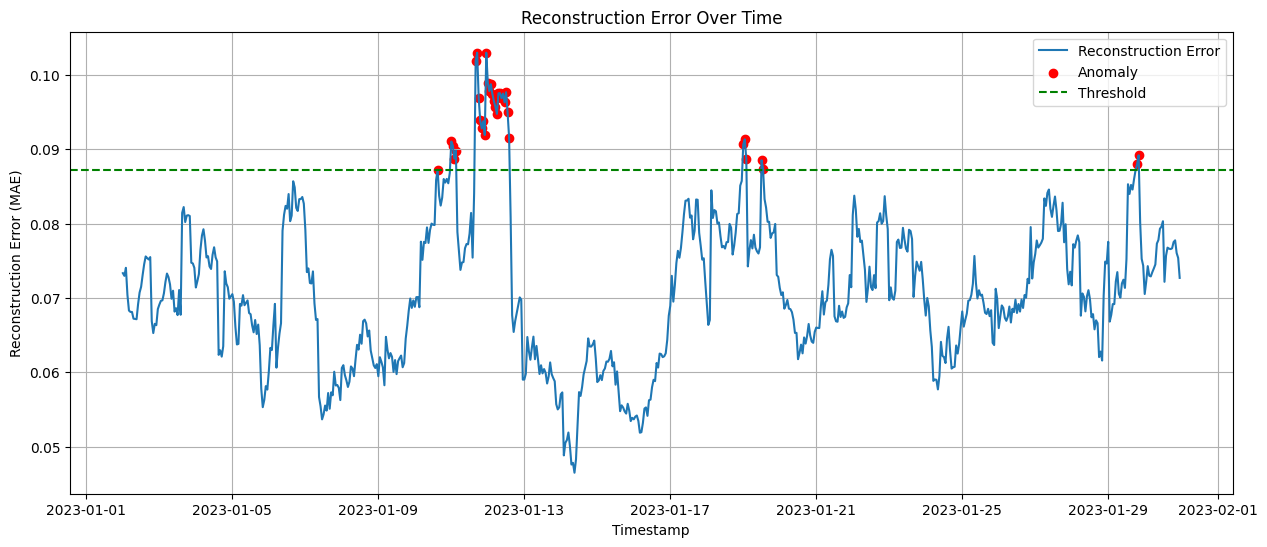

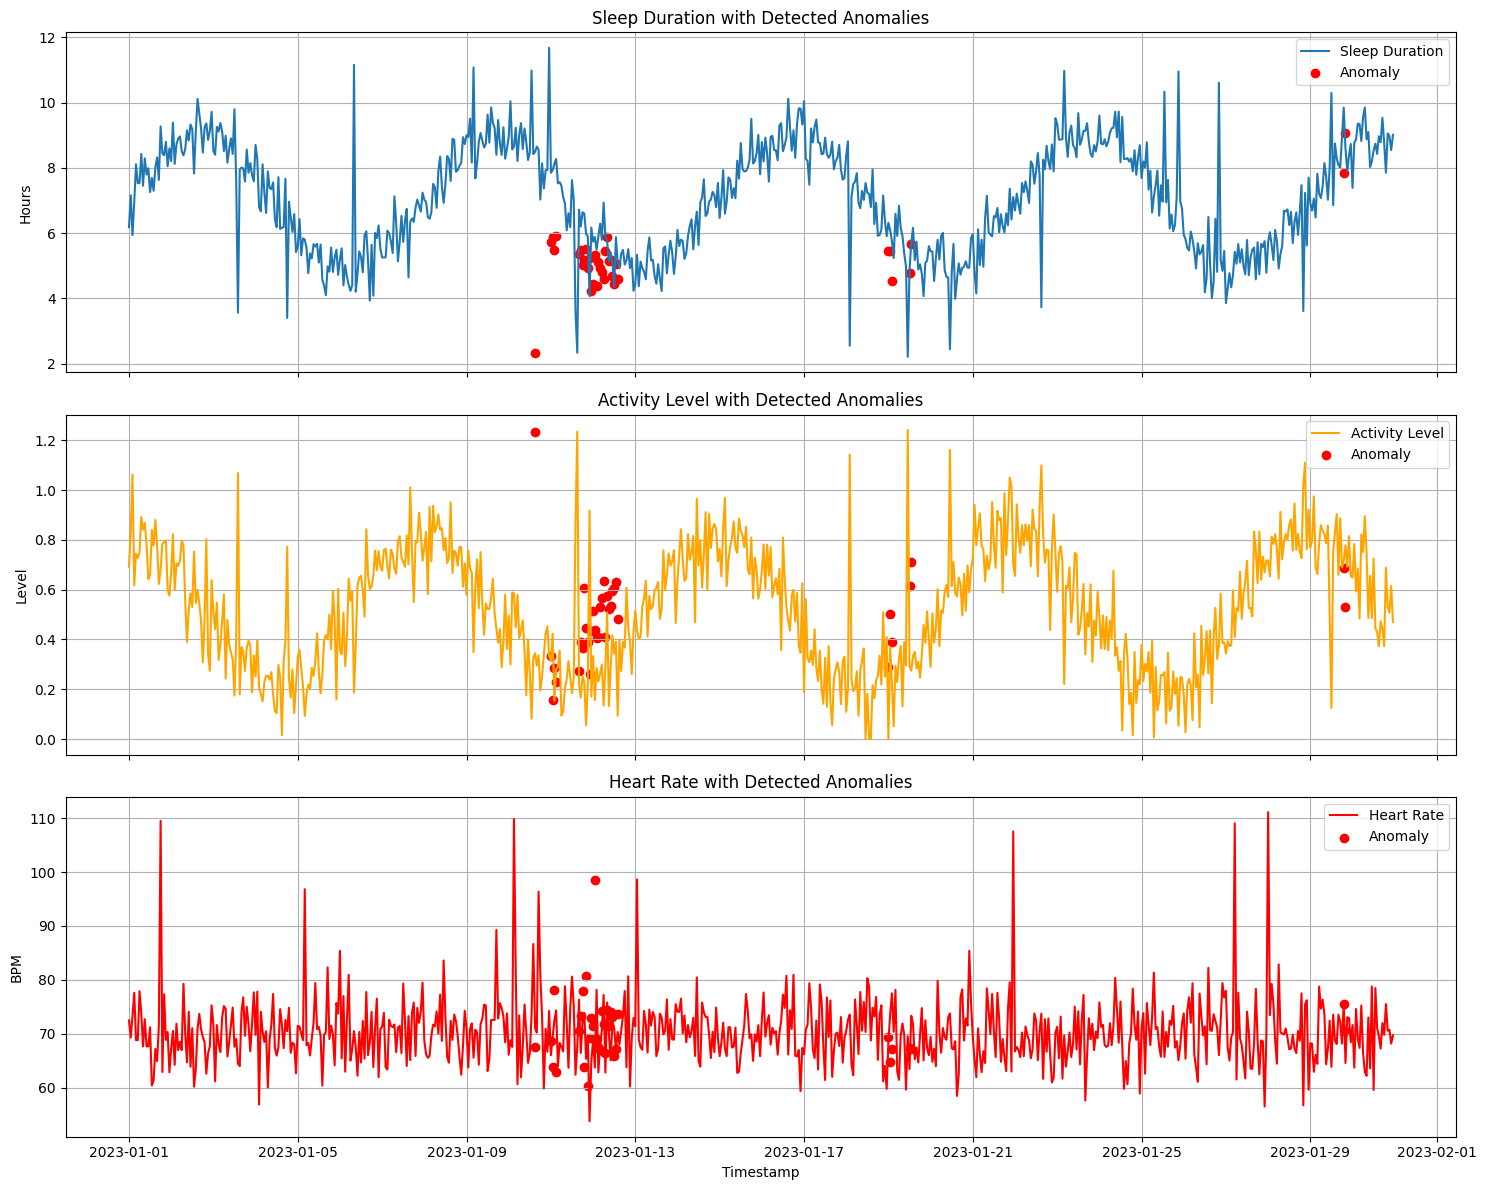

In [5]:
# Get reconstructions
X_pred = model.predict(X)
X_pred = X_pred.reshape(X_pred.shape[0], X_pred.shape[1] * X_pred.shape[2]) # Flatten for error calculation
X_true = X.reshape(X.shape[0], X.shape[1] * X.shape[2]) # Flatten for error calculation

# Calculate reconstruction error (MAE)
reconstruction_errors = np.mean(np.abs(X_pred - X_true), axis=1)

# The reconstruction errors correspond to the *end* of each sequence
# We need to align them with the original dataframe timestamps
# The first `SEQUENCE_LENGTH` data points won't have a reconstruction error
# because they were used to form the first sequence.

# Create a series for reconstruction errors aligned with timestamps
error_df = pd.DataFrame({'reconstruction_error': reconstruction_errors,
                         'timestamp': df['timestamp'][SEQUENCE_LENGTH:]})

# Determine a threshold for anomalies
# A common approach is to use a percentile or standard deviation based threshold
threshold = np.percentile(reconstruction_errors, 95) # Flag top 5% as anomalies
print(f"Anomaly threshold: {threshold:.4f}")

# Detect anomalies
anomalies = error_df[error_df['reconstruction_error'] > threshold]

# Plot reconstruction errors over time
plt.figure(figsize=(15, 6))
plt.plot(error_df['timestamp'], error_df['reconstruction_error'], label='Reconstruction Error')
plt.scatter(anomalies['timestamp'], anomalies['reconstruction_error'], color='r', label='Anomaly')
plt.axhline(y=threshold, color='g', linestyle='--', label='Threshold')
plt.title('Reconstruction Error Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Reconstruction Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

# Visualize anomalies on the original data
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 12), sharex=True)

# Plot Sleep Duration with Anomalies
axes[0].plot(df['timestamp'], df['sleep_duration'], label='Sleep Duration')
axes[0].scatter(anomalies['timestamp'], df['sleep_duration'][anomalies.index + SEQUENCE_LENGTH], color='r', label='Anomaly')
axes[0].set_ylabel('Hours')
axes[0].set_title('Sleep Duration with Detected Anomalies')
axes[0].legend()
axes[0].grid(True)

# Plot Activity Level with Anomalies
axes[1].plot(df['timestamp'], df['activity_level'], label='Activity Level', color='orange')
axes[1].scatter(anomalies['timestamp'], df['activity_level'][anomalies.index + SEQUENCE_LENGTH], color='r', label='Anomaly')
axes[1].set_ylabel('Level')
axes[1].set_title('Activity Level with Detected Anomalies')
axes[1].legend()
axes[1].grid(True)

# Plot Heart Rate with Anomalies
axes[2].plot(df['timestamp'], df['heart_rate'], label='Heart Rate', color='red')
axes[2].scatter(anomalies['timestamp'], df['heart_rate'][anomalies.index + SEQUENCE_LENGTH], color='r', label='Anomaly')
axes[2].set_ylabel('BPM')
axes[2].set_title('Heart Rate with Detected Anomalies')
axes[2].legend()
axes[2].grid(True)

plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 3)          │           387 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,219 (973.51 KB)

 Trainable params: 249,219 (973.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - loss: 0.2640 - val_loss: 0.1864
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.1598 - val_loss: 0.1493
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.1427 - val_loss: 0.1444
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.1401 - val_loss: 0.1335
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - loss: 0.1246 - val_loss: 0.1350
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.1260 - val_loss: 0.2067
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.1343 - val_loss: 0.1174
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.1062 - val_loss: 0.1168
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.1000 - val_loss: 0.1183
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.1142 - val_loss: 0.1170
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - loss: 0.0967 - val_loss: 0.0976
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss:

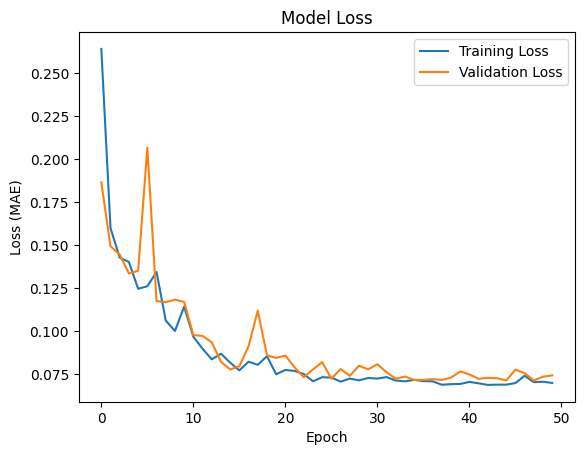

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

# Define the LSTM Autoencoder model
def build_lstm_autoencoder(timesteps, n_features):
    model = keras.Sequential([
        layers.LSTM(128, activation='relu', input_shape=(timesteps, n_features), return_sequences=True),
        layers.LSTM(64, activation='relu', return_sequences=False),
        layers.RepeatVector(timesteps),
        layers.LSTM(64, activation='relu', return_sequences=True),
        layers.LSTM(128, activation='relu', return_sequences=True),
        layers.TimeDistributed(layers.Dense(n_features))
    ])
    model.compile(optimizer='adam', loss='mae') # Using Mean Absolute Error for anomaly detection
    return model

# Get dimensions for the model
timesteps = X.shape[1]
n_features = X.shape[2]

# Build the model
model = build_lstm_autoencoder(timesteps, n_features)
model.summary()

# Train the model
history = model.fit(X, X, epochs=50, batch_size=32, validation_split=0.1, verbose=1, shuffle=False)

# Plot training loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.show()

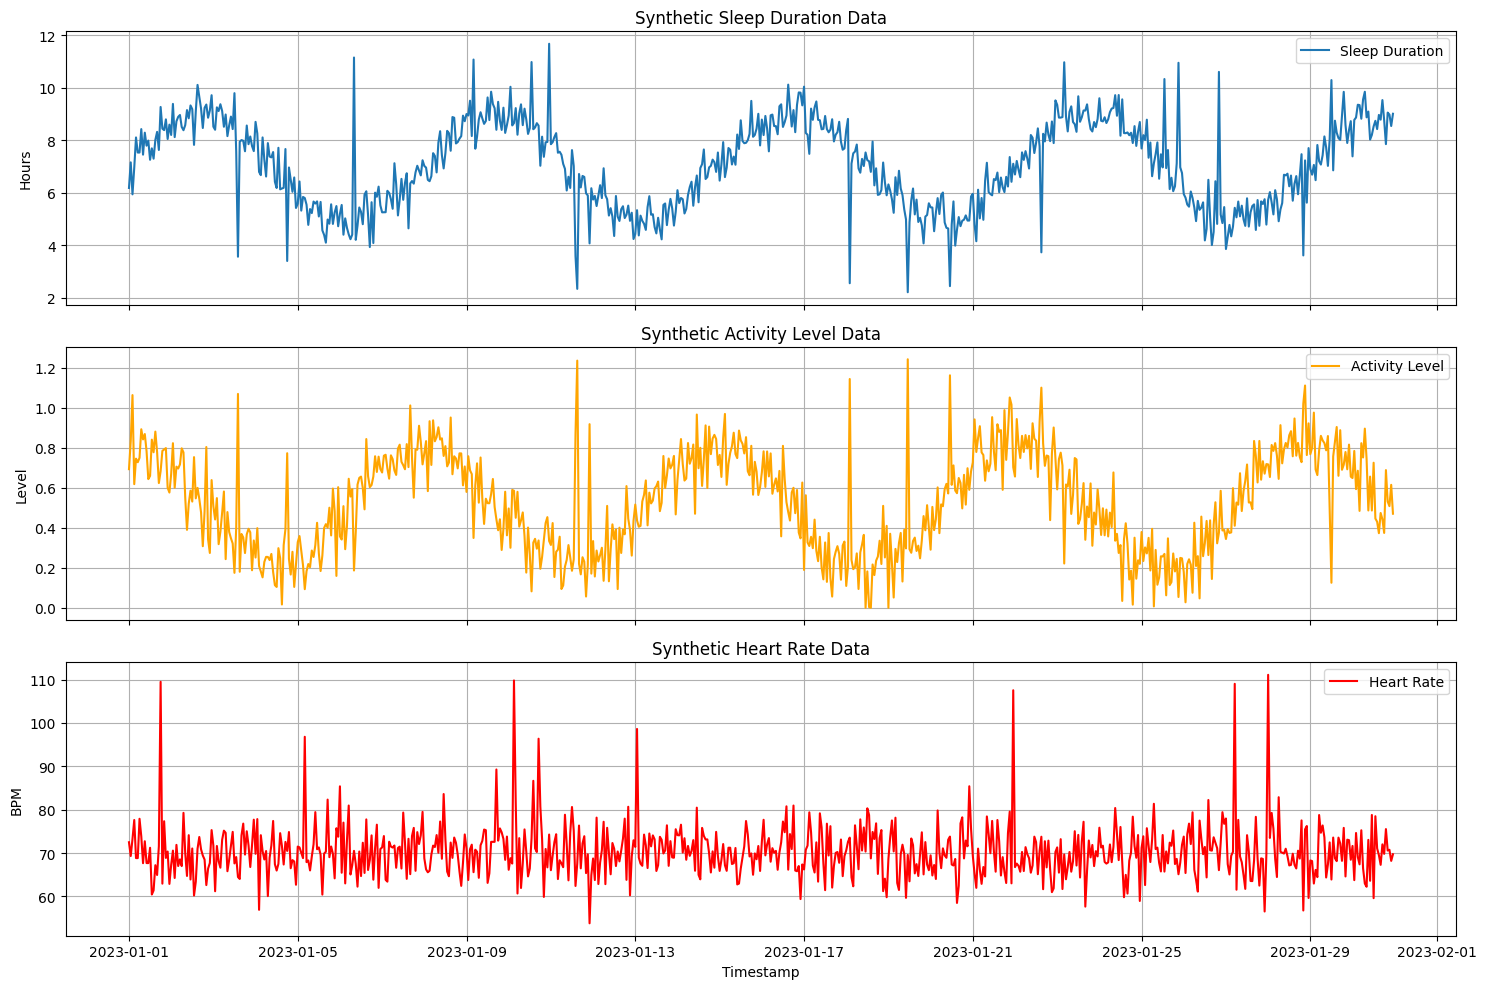

In [2]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True)

axes[0].plot(df['timestamp'], df['sleep_duration'], label='Sleep Duration')
axes[0].set_ylabel('Hours')
axes[0].set_title('Synthetic Sleep Duration Data')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df['timestamp'], df['activity_level'], label='Activity Level', color='orange')
axes[1].set_ylabel('Level')
axes[1].set_title('Synthetic Activity Level Data')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(df['timestamp'], df['heart_rate'], label='Heart Rate', color='red')
axes[2].set_ylabel('BPM')
axes[2].set_title('Synthetic Heart Rate Data')
axes[2].legend()
axes[2].grid(True)

plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()
